In [ ]:
import pandas as pd

ccna_df = pd.read_csv("/content/data-2025-10-20T19_42_06.253Z.csv")

print("✅ Dataset Shape:", ccna_df.shape)
print("\n🧾 First 50 column names:\n", list(ccna_df.columns[:50]))
print("\n🔍 Sample rows:\n", ccna_df.head(2))


✅ Dataset Shape: (1173, 86)

🧾 First 50 column names:
 ['Identifiers', 'Clinical_Assessment General_Health_Sleep,000_Date_taken', 'Clinical_Assessment General_Health_Sleep,001_Candidate_Age', 'Clinical_Assessment General_Health_Sleep,002_Window_Difference', 'Clinical_Assessment General_Health_Sleep,003_Examiner', 'Clinical_Assessment General_Health_Sleep,004_PSQISLPQUAL', 'Clinical_Assessment General_Health_Sleep,005_PSQILATEN', 'Clinical_Assessment General_Health_Sleep,006_PSQIDURAT', 'Clinical_Assessment General_Health_Sleep,007_PSQIHSE', 'Clinical_Assessment General_Health_Sleep,008_PSQIDISTB', 'Clinical_Assessment General_Health_Sleep,009_PSQIMEDS', 'Clinical_Assessment General_Health_Sleep,010_PSQIDAYDYS', 'Clinical_Assessment General_Health_Sleep,011_psqi', 'Clinical_Assessment General_Health_Sleep,012_q1_bed_time_te', 'Clinical_Assessment General_Health_Sleep,013_q1_bed_time_te_status', 'Clinical_Assessment General_Health_Sleep,014_q2_sleep_te', 'Clinical_Assessment General_Heal


✅ Accuracy: 0.5471698113207547

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.56      0.56        80
           1       0.55      0.53      0.54        79

    accuracy                           0.55       159
   macro avg       0.55      0.55      0.55       159
weighted avg       0.55      0.55      0.55       159

🧩 Confusion Matrix:
 [[45 35]
 [37 42]]


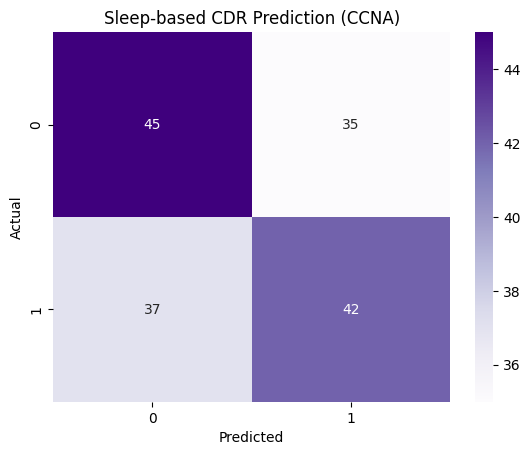

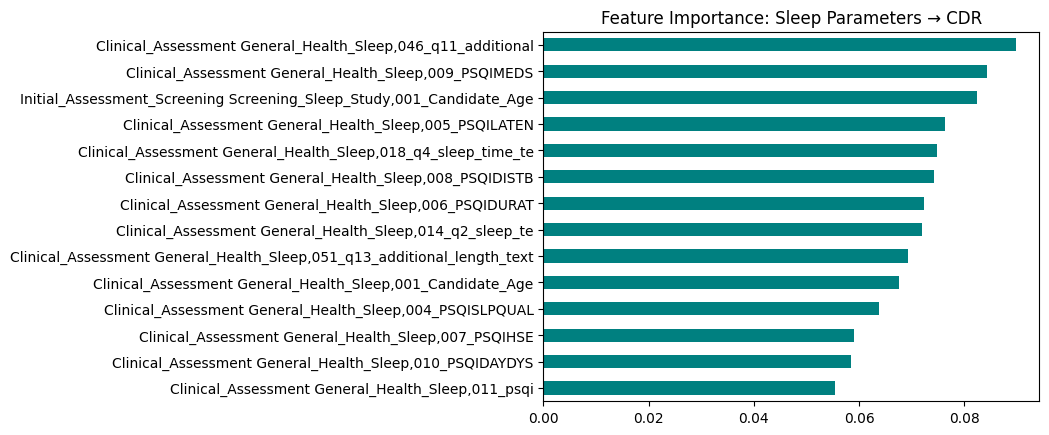

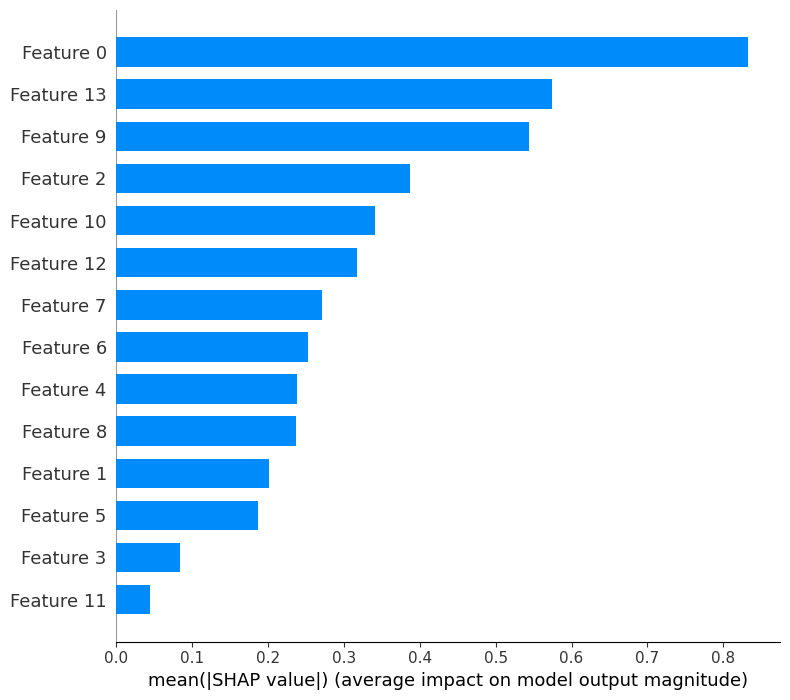


✅ Saved: ccna_sleep_to_cdr_model.pkl


In [ ]:
# ============================================
# ✅ CCNA Sleep Parameters → CDR Model
# ============================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
import shap
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
ccna_df = pd.read_csv("/content/data-2025-10-20T19_42_06.253Z.csv")

# Rename CDR column for easier access
ccna_df = ccna_df.rename(columns={
    'Initial_Assessment_Screening Screening_Clinical_Dementia_Rating,013_global_CDR': 'CDR'
})

# Select features containing sleep parameters (PSQI-related)
sleep_cols = [col for col in ccna_df.columns if 'PSQI' in col.upper() or 'SLEEP' in col.upper()]
X = ccna_df[sleep_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Target variable → CDR
ccna_df['CDR'] = pd.to_numeric(ccna_df['CDR'], errors='coerce')
df = ccna_df.dropna(subset=['CDR'])
y = df['CDR'].apply(lambda x: 0 if x == 0 else 1).astype(int)  # 0 = Normal, 1 = Impaired
X = X.loc[df.index]

# ⚖️ Scale + SMOTE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# 🔍 Feature Selection
selector_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='mlogloss', random_state=42)
selector_model.fit(X_resampled, y_resampled)
selector = SelectFromModel(selector_model, prefit=True, threshold="mean")
X_selected = selector.transform(X_resampled)

# 🧪 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# 🚀 Final Model
xgb_final_ccna = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.3,
    eval_metric='mlogloss',
    random_state=42
)
xgb_final_ccna.fit(X_train, y_train)

# 📊 Evaluate
y_pred = xgb_final_ccna.predict(X_test)
print("\n✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Sleep-based CDR Prediction (CCNA)")
plt.show()

# 5️⃣ Feature Importance
feat_imp = pd.Series(xgb_final_ccna.feature_importances_, index=np.array(sleep_cols)[selector.get_support()]).sort_values(ascending=True)
feat_imp.plot(kind="barh", color="teal")
plt.title("Feature Importance: Sleep Parameters → CDR")
plt.show()

# 6️⃣ SHAP (optional)
explainer = shap.TreeExplainer(xgb_final_ccna)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

# 💾 Save model
with open("ccna_sleep_to_cdr_model.pkl", "wb") as f:
    pickle.dump(xgb_final_ccna, f)
print("\n✅ Saved: ccna_sleep_to_cdr_model.pkl")


=== CDR Stage Distribution ===
CDR = 0.0: 396 subjects
CDR = 0.5: 364 subjects
CDR = 1.0: 8 subjects


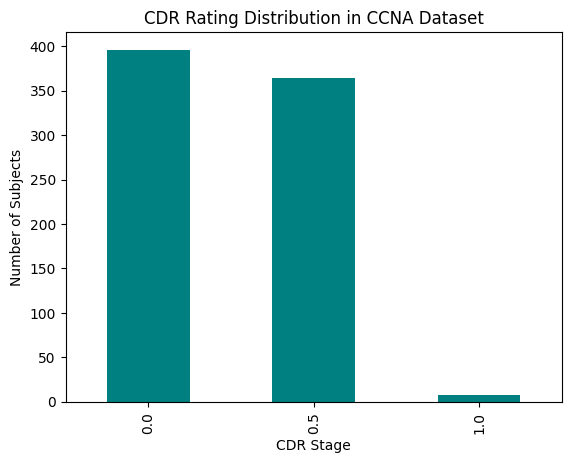

In [ ]:
import pandas as pd

# Load dataset
ccna_df = pd.read_csv("/content/data-2025-10-20T19_42_06.253Z.csv")

# Convert the CDR column to numeric
ccna_df['Initial_Assessment_Screening Screening_Clinical_Dementia_Rating,013_global_CDR'] = pd.to_numeric(
    ccna_df['Initial_Assessment_Screening Screening_Clinical_Dementia_Rating,013_global_CDR'],
    errors='coerce'
)

# Drop NaNs and count unique categories
cdr_counts = ccna_df['Initial_Assessment_Screening Screening_Clinical_Dementia_Rating,013_global_CDR'].value_counts().sort_index()

# Display the distribution
print("=== CDR Stage Distribution ===")
for stage, count in cdr_counts.items():
    print(f"CDR = {stage}: {count} subjects")

# Optional: visualize it
import matplotlib.pyplot as plt
cdr_counts.plot(kind='bar', color='teal')
plt.title("CDR Rating Distribution in CCNA Dataset")
plt.xlabel("CDR Stage")
plt.ylabel("Number of Subjects")
plt.show()


In [ ]:
# ✅ Convert SMOTE labels back to numeric integers
label_mapping = {'0.0': 0, '0.5': 1, '1.0': 2}
y_resampled = y_resampled.map(label_mapping)
y_resampled = y_resampled.astype(int)

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# XGBoost Model
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.3,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = xgb_model.predict(X_test)
print("\n✅ Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



✅ Accuracy: 0.693

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.51      0.53        79
           1       0.54      0.63      0.58        79
           2       1.00      0.94      0.97        80

    accuracy                           0.69       238
   macro avg       0.70      0.69      0.70       238
weighted avg       0.70      0.69      0.70       238

🧩 Confusion Matrix:
 [[40 39  0]
 [29 50  0]
 [ 2  3 75]]


Before SMOTE: Counter({'0.0': 396, '0.5': 364, '1.0': 8})
After SMOTE: Counter({'0.0': 396, '0.5': 396, '1.0': 396})

🔍 Running cross-validation to find best number of trees...
✅ Optimal number of trees: 339

✅ Accuracy: 0.714

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.53      0.56        79
           1       0.57      0.67      0.62        79
           2       1.00      0.94      0.97        80

    accuracy                           0.71       238
   macro avg       0.72      0.71      0.72       238
weighted avg       0.72      0.71      0.72       238

🧩 Confusion Matrix:
 [[42 37  0]
 [26 53  0]
 [ 2  3 75]]


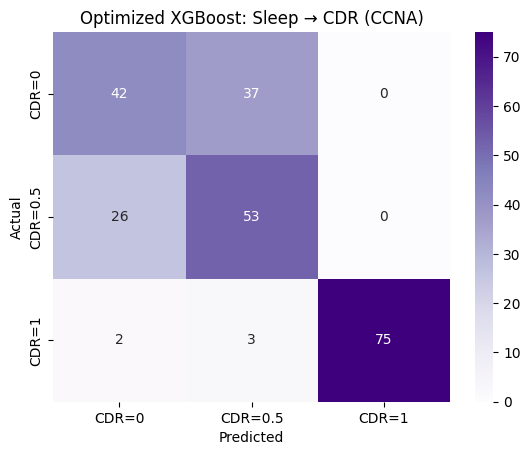

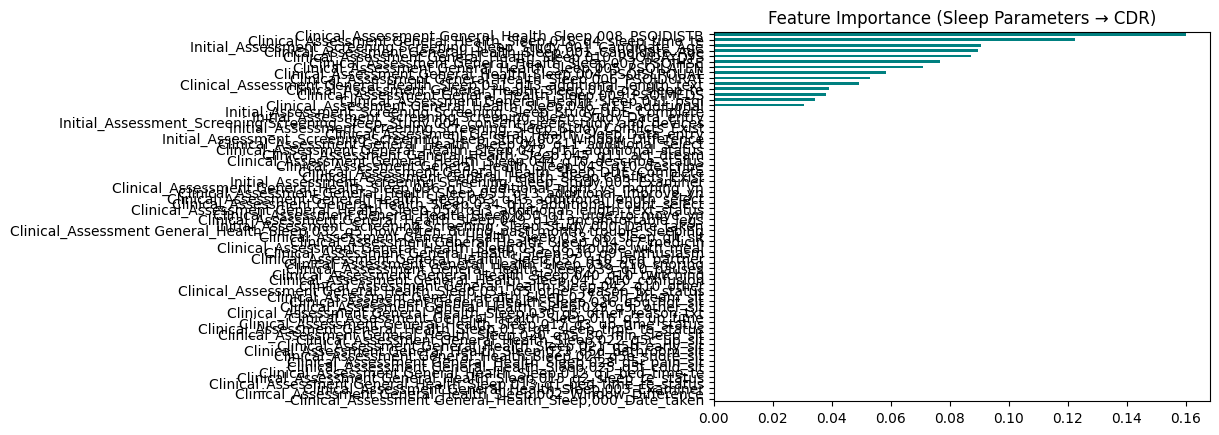

/tmp/ipython-input-246843235.py:131: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)


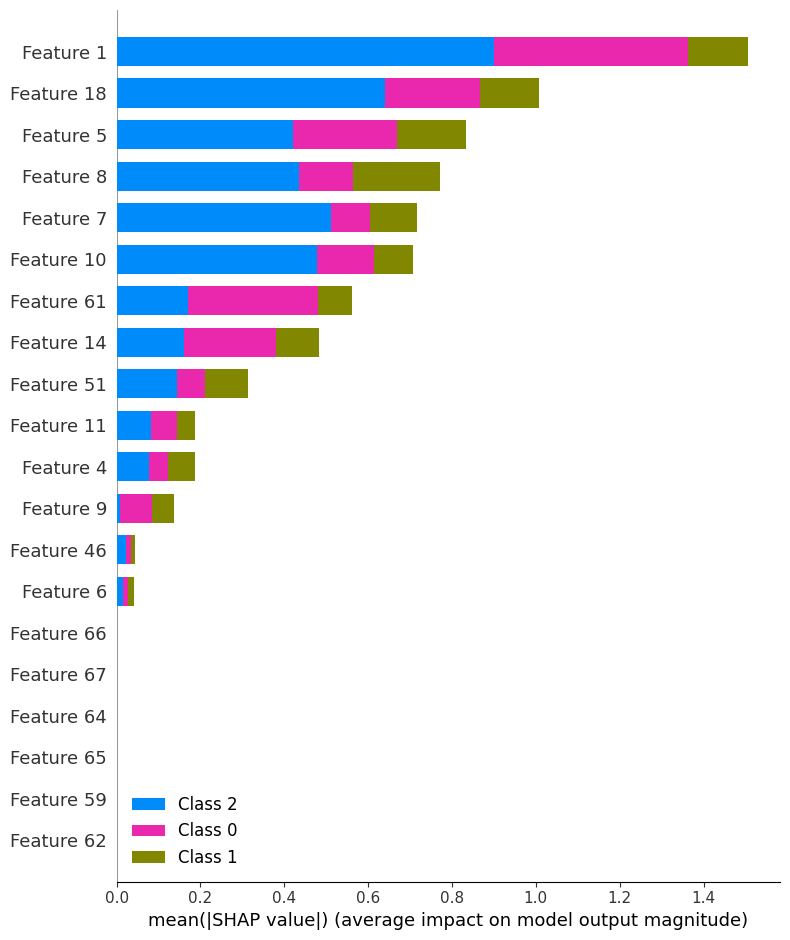


✅ Model saved as: optimized_ccna_sleep_cdr_model.pkl


In [ ]:
# ============================================
# 🚀 Optimized XGBoost-only Model (Sleep → CDR)
# ============================================

import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
import shap
import pickle

# 1️⃣ Load Dataset
ccna_df = pd.read_csv("/content/data-2025-10-20T19_42_06.253Z.csv")

# Rename the target column
ccna_df = ccna_df.rename(columns={
    'Initial_Assessment_Screening Screening_Clinical_Dementia_Rating,013_global_CDR': 'CDR'
})

# 2️⃣ Select all PSQI + SLEEP features
sleep_cols = [col for col in ccna_df.columns if 'PSQI' in col.upper() or 'SLEEP' in col.upper()]
X = ccna_df[sleep_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# 3️⃣ Prepare target variable
ccna_df['CDR'] = pd.to_numeric(ccna_df['CDR'], errors='coerce')
df = ccna_df.dropna(subset=['CDR'])
y = df['CDR']

# Convert continuous to discrete categorical
y = y.apply(lambda x: 0.0 if x == 0 else (0.5 if x == 0.5 else 1.0))
y = y.astype(str)
X = X.loc[df.index]

# 4️⃣ Scale + SMOTE to balance classes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before SMOTE:", Counter(y))

smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("After SMOTE:", Counter(y_resampled))

# Convert labels to integers for XGBoost
label_mapping = {'0.0': 0, '0.5': 1, '1.0': 2}
y_resampled = y_resampled.map(label_mapping).astype(int)

# 5️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# 6️⃣ Use cross-validation to find best n_estimators
dtrain = xgb.DMatrix(X_train, label=y_train)
params = {
    'objective': 'multi:softmax',
    'num_class': 3,
    'learning_rate': 0.03,
    'max_depth': 5,
    'min_child_weight': 3,
    'gamma': 0.2,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'reg_lambda': 2.0,
    'reg_alpha': 0.6,
    'eval_metric': 'mlogloss'
}

print("\n🔍 Running cross-validation to find best number of trees...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=1000,
    nfold=5,
    early_stopping_rounds=30,
    seed=42,
    metrics='mlogloss',
    verbose_eval=False
)
best_round = len(cv_results)
print(f"✅ Optimal number of trees: {best_round}")

# 7️⃣ Train final model with optimized parameters
xgb_final = XGBClassifier(
    n_estimators=best_round,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=2.0,
    reg_alpha=0.6,
    eval_metric='mlogloss',
    random_state=42
)
xgb_final.fit(X_train, y_train)

# 8️⃣ Evaluate
y_pred = xgb_final.predict(X_test)
print("\n✅ Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['CDR=0', 'CDR=0.5', 'CDR=1'],
            yticklabels=['CDR=0', 'CDR=0.5', 'CDR=1'])
plt.title("Optimized XGBoost: Sleep → CDR (CCNA)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# 🔟 Feature Importance
feat_imp = pd.Series(xgb_final.feature_importances_, index=sleep_cols[:len(xgb_final.feature_importances_)])
feat_imp.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Feature Importance (Sleep Parameters → CDR)")
plt.show()

# 🔹 Optional SHAP (Explainability)
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

# 💾 Save Model
with open("optimized_ccna_sleep_cdr_model.pkl", "wb") as f:
    pickle.dump(xgb_final, f)

print("\n✅ Model saved as: optimized_ccna_sleep_cdr_model.pkl")


In [ ]:
# ==============================================================
# 📈 SAVE CCNA SLEEP→CDR MODEL RESULTS IN CSF-STYLE FORMAT
# ==============================================================

import shap, pickle, numpy as np
from sklearn.metrics import confusion_matrix

# --- Predictions and probabilities ---
y_pred = xgb_final.predict(X_test)
p_pred = xgb_final.predict_proba(X_test)

# --- Compute SHAP feature importances ---
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_train)

# Handle multiclass SHAP output
if isinstance(shap_values, list):
    shap_values = np.array(shap_values).mean(axis=0)  # take mean importance across classes

# --- Compute mean absolute SHAP for each feature ---
shap_importance = dict(zip(
    sleep_cols[:len(xgb_final.feature_importances_)],
    np.abs(shap_values).mean(axis=0)
))

# --- Build unified dictionary (CSF-style) ---
ccna_sleep_results = {
    "model": xgb_final,
    "y_pred": y_pred,
    "p_pred": p_pred,
    "cm": confusion_matrix(y_test, y_pred).tolist(),
    "shap_importance": shap_importance
}

# --- Save as .pkl file ---
with open("ccna_sleep_results.pkl", "wb") as f:
    pickle.dump(ccna_sleep_results, f)

print("\n💾 Saved: ccna_sleep_results.pkl — ready for cross-cohort comparison with ADNI sleep model.")



💾 Saved: ccna_sleep_results.pkl — ready for cross-cohort comparison with ADNI sleep model.
